In [13]:
import torch
import torch.nn as nn
from torchvision.datasets import Flowers102
import matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np


In [ ]:
train_ds=Flowers102(root="data",split="train",download=True)

100%|██████████| 345M/345M [15:22<00:00, 374kB/s]   
100%|██████████| 502/502 [00:00<00:00, 250kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 7.49MB/s]


In [10]:
len(train_ds)

1020

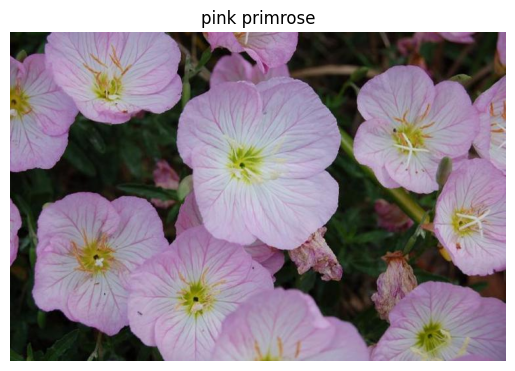

In [ ]:
image, label = train_ds[0]
plt.imshow(image)
plt.title(train_ds.classes[label])
plt.axis("off")
plt.show()

In [21]:
### image of pillow type
image, label = train_ds[20]
print(type(image))

<class 'PIL.Image.Image'>


In [18]:
def show_image(image,title=""):
    plt.axis("off")
    plt.imshow(image)
    plt.title(title)
    plt.show()

#### Transformation on PIL image

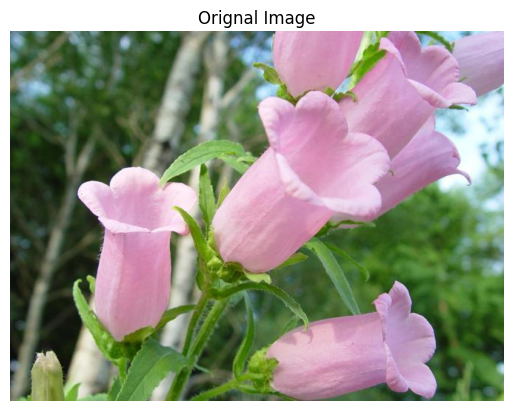

In [22]:
show_image(image=image, title="Orignal Image")

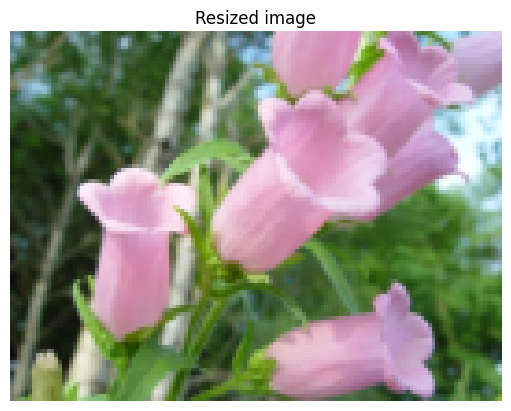

In [27]:
resize=transforms.Resize(100) ## lower resolution
resized_image=resize(image)
show_image(resized_image,"Resized image")

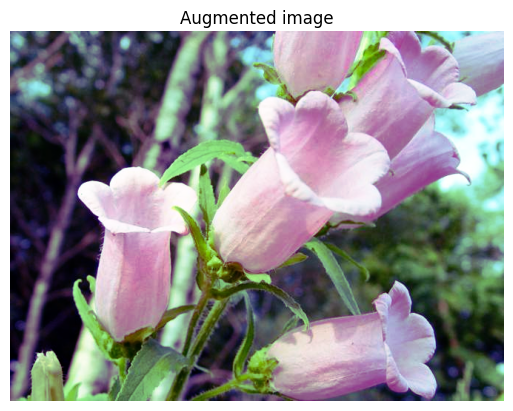

In [ ]:
aug=transforms.AutoAugment()
auto_aug=aug(image)
show_image(auto_aug,title="Augmented image")

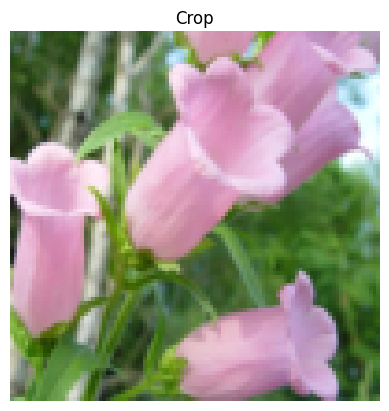

In [57]:
crop=transforms.RandomResizedCrop(100) ### randomly crops a part of image
cropped_img=crop(image)
show_image(cropped_img,"Crop")

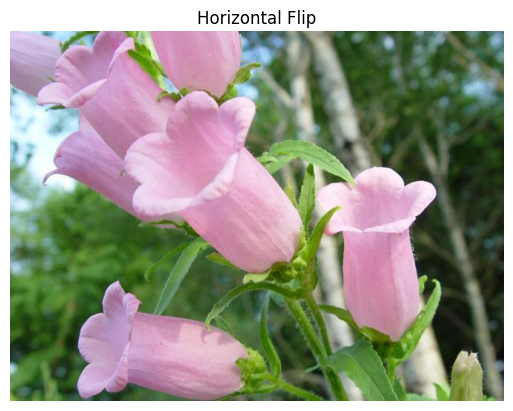

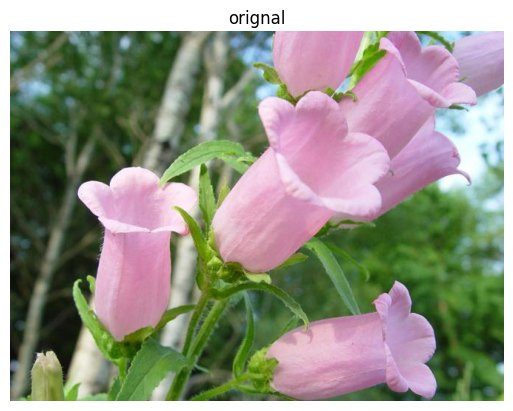

In [67]:
flip = transforms.RandomHorizontalFlip(p=0.5)  # force flip for visualization
img_flip = flip(image)

show_image(img_flip, "Horizontal Flip")
show_image(image, "orignal")

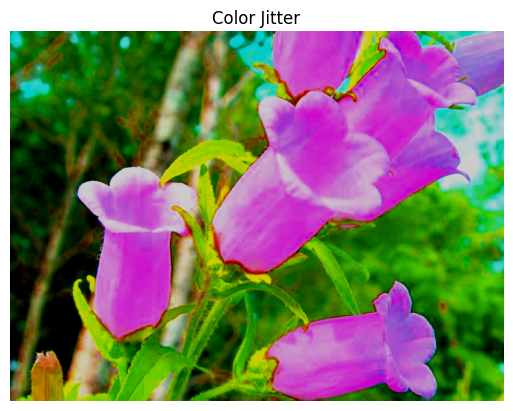

In [70]:
cj = transforms.ColorJitter(
    brightness=0.5,
    contrast=0.5,
    saturation=3,
    hue=0.1
)

img_cj = cj(image)

show_image(img_cj, "Color Jitter")

#### Transformation on tensor image

In [71]:
to_tensor = transforms.ToTensor()
img_tensor = to_tensor(image)

print(img_tensor.shape)

torch.Size([3, 500, 667])


In [72]:
standarize=transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
normaized_image=standarize(img_tensor)

In [ ]:
normaized_image[0].mean()  

tensor(0.1530)

##### Transform pipeline

In [ ]:
transform=transforms.Compose([
    transforms.RandomResizedCrop(250),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2,0.3,0.3,0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])
])